# Champions Predictor - Power Rating Model

## Enfoque
**Stats de temporada → Power Rating → Simulación**

Sin ratings ELO manuales. Todo basado en datos objetivos de la temporada 2024-25.

## Variables (solo datos disponibles)
1. Points per game (liga)
2. Goals scored per game (liga)
3. Goals conceded per game (liga)
4. Goal difference per game (liga)
5. Champions League points per game
6. Champions League goal difference per game

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px

## 1. Cargar Datos

In [2]:
# Cargar stats
df = pd.read_csv('../data/raw/team_stats_2024_25.csv')
print(f"✅ Datos cargados: {len(df)} equipos\n")
print(df.head())

✅ Datos cargados: 16 equipos

             Equipo            Liga  Pj  Pts  GF  GC  champions_pj  Champ_Pts  \
0           Arsenal  Premier League  30   67  59  22             8         24   
1   Manchester City  Premier League  29   60  59  27             8         16   
2           Chelsea  Premier League  29   48  53  34             8         16   
3         Liverpool  Premier League  29   48  48  39             8         18   
4  Newcastle United  Premier League  29   39  42  43            10         20   

   Champ_GF  Champ_GC  
0        23         4  
1        15         9  
2        17        10  
3        20         8  
4        26        10  


## 2. Feature Engineering

### 2.1 Multiplicadores por Liga

**Problema identificado:** Las stats de liga no consideran nivel de competencia.

**Solución:** Aplicar multiplicadores basados en coeficiente UEFA / nivel de liga:
- Premier League: 1.00 (referencia - liga más fuerte)
- La Liga: 0.95
- Bundesliga: 0.93
- Serie A: 0.90
- Ligue 1: 0.85
- Primeira Liga: 0.70 ⚠️
- Süper Lig: 0.65 ⚠️
- Eliteserien: 0.50 ⚠️

Así, 2.5 PPG en Portugal ≠ 2.5 PPG en Premier League

In [3]:
# Multiplicadores de liga (basados en nivel de competencia)
liga_multipliers = {
    'Premier League': 1.00,    # Referencia (liga más competitiva)
    'La Liga': 0.95,           # Segunda más fuerte
    'Bundesliga': 0.93,        # Tercera
    'Serie A': 0.90,           # Cuarta
    'Ligue 1': 0.85,           # Quinta (PSG domina)
    'Primeira Liga': 0.70,     # Liga más débil (top 3 dominan)
    'Süper Lig': 0.65,         # Similar a Portugal
    'Eliteserien': 0.50        # Liga nórdica (nivel más bajo)
}

print("🌍 MULTIPLICADORES POR LIGA:")
print("="*50)
for liga, mult in sorted(liga_multipliers.items(), key=lambda x: x[1], reverse=True):
    print(f"{liga:20s}: {mult:.2f}x")
print("="*50)

🌍 MULTIPLICADORES POR LIGA:
Premier League      : 1.00x
La Liga             : 0.95x
Bundesliga          : 0.93x
Serie A             : 0.90x
Ligue 1             : 0.85x
Primeira Liga       : 0.70x
Süper Lig           : 0.65x
Eliteserien         : 0.50x


### 2.2 Calcular Métricas (con ajuste por liga)

In [4]:
# LIGA - Stats per game (SIN ajustar aún)
df['ppg_liga_raw'] = df['Pts'] / df['Pj']
df['gf_pg_liga_raw'] = df['GF'] / df['Pj']
df['gc_pg_liga_raw'] = df['GC'] / df['Pj']
df['gd_pg_liga_raw'] = (df['GF'] - df['GC']) / df['Pj']

# Aplicar multiplicador de liga
df['liga_multiplier'] = df['Liga'].map(liga_multipliers)

# Stats AJUSTADAS por nivel de liga
df['ppg_liga'] = df['ppg_liga_raw'] * df['liga_multiplier']
df['gf_pg_liga'] = df['gf_pg_liga_raw'] * df['liga_multiplier']
df['gd_pg_liga'] = df['gd_pg_liga_raw'] * df['liga_multiplier']

# Defensa ajustada (inverso, entonces dividimos)
df['defensa_score'] = (1 / (df['gc_pg_liga_raw'] + 0.1)) * df['liga_multiplier']

# CHAMPIONS - Stats per game (NO ajustar - todos contra mismo nivel)
df['ppg_champions'] = df['Champ_Pts'] / df['champions_pj']
df['gf_pg_champions'] = df['Champ_GF'] / df['champions_pj']
df['gc_pg_champions'] = df['Champ_GC'] / df['champions_pj']
df['gd_pg_champions'] = (df['Champ_GF'] - df['Champ_GC']) / df['champions_pj']

print("\n✅ Features calculados (con ajuste por liga)\n")
print("📊 COMPARACIÓN - Stats RAW vs AJUSTADAS:\n")
print(df[['Equipo', 'Liga', 'ppg_liga_raw', 'ppg_liga', 'liga_multiplier']].head(10))


✅ Features calculados (con ajuste por liga)

📊 COMPARACIÓN - Stats RAW vs AJUSTADAS:

              Equipo            Liga  ppg_liga_raw  ppg_liga  liga_multiplier
0            Arsenal  Premier League      2.233333  2.233333             1.00
1    Manchester City  Premier League      2.068966  2.068966             1.00
2            Chelsea  Premier League      1.655172  1.655172             1.00
3          Liverpool  Premier League      1.655172  1.655172             1.00
4   Newcastle United  Premier League      1.344828  1.344828             1.00
5  Tottenham Hotspur  Premier League      1.000000  1.000000             1.00
6        Real Madrid         La Liga      2.333333  2.216667             0.95
7          Barcelona         La Liga      2.461538  2.338462             0.95
8    Atlético Madrid         La Liga      1.961538  1.863462             0.95
9      Bayern Munich      Bundesliga      2.640000  2.455200             0.93


## 3. Normalización Manual (0-1)

Normalizar features a escala 0-1:

In [5]:
# Función de normalización simple
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

# Features a normalizar
features = [
    'ppg_liga',
    'gf_pg_liga',
    'gd_pg_liga',
    'defensa_score',
    'ppg_champions',
    'gd_pg_champions'
]

# Normalizar cada feature
for feature in features:
    df[f'{feature}_norm'] = normalize(df[feature])

print("✅ Features normalizados (0-1)\n")
print("Ejemplo - Arsenal:")
arsenal_data = df[df['Equipo'] == 'Arsenal'][['Equipo', 'ppg_liga', 'ppg_liga_norm', 'gd_pg_liga', 'gd_pg_liga_norm']]
print(arsenal_data)

✅ Features normalizados (0-1)

Ejemplo - Arsenal:
    Equipo  ppg_liga  ppg_liga_norm  gd_pg_liga  gd_pg_liga_norm
0  Arsenal  2.233333       0.847535    1.233333         0.532199


## 4. Power Rating Formula

### Pesos de cada componente:
```
Power Score = 
    0.30 * ppg_liga_norm          (forma en liga - 30%)
  + 0.25 * gd_pg_liga_norm        (diferencia goles liga - 25%)
  + 0.15 * gf_pg_liga_norm        (ataque liga - 15%)
  + 0.10 * defensa_score_norm     (defensa liga - 10%)
  + 0.15 * ppg_champions_norm     (performance Champions - 15%)
  + 0.05 * gd_pg_champions_norm   (diferencia goles Champions - 5%)
```

**Total = 100%**

In [6]:
# Calcular Power Score (0-1)
df['power_score'] = (
    0.30 * df['ppg_liga_norm'] +
    0.25 * df['gd_pg_liga_norm'] +
    0.15 * df['gf_pg_liga_norm'] +
    0.10 * df['defensa_score_norm'] +
    0.15 * df['ppg_champions_norm'] +
    0.05 * df['gd_pg_champions_norm']
)

# Escalar a rating (1600-2000)
min_rating = 1600
max_rating = 2000

df['power_rating'] = min_rating + (max_rating - min_rating) * df['power_score']

# Ordenar por rating
df_rankings = df[[
    'Equipo', 'power_rating', 'power_score',
    'ppg_liga', 'gd_pg_liga', 'ppg_champions'
]].sort_values('power_rating', ascending=False).reset_index(drop=True)

df_rankings['ranking'] = range(1, len(df_rankings) + 1)

print("\n🏆 POWER RATINGS - Champions League 2024-25\n")
print(df_rankings[['ranking', 'Equipo', 'power_rating']].to_string(index=False))


🏆 POWER RATINGS - Champions League 2024-25

 ranking              Equipo  power_rating
       1       Bayern Munich   1963.480130
       2             Arsenal   1895.024032
       3           Barcelona   1870.061731
       4         Real Madrid   1837.363398
       5     Manchester City   1816.810440
       6     Sporting Lisboa   1810.512069
       7 Paris Saint-Germain   1790.173315
       8     Atlético Madrid   1760.739370
       9             Chelsea   1751.615136
      10           Liverpool   1743.293522
      11    Bayer Leverkusen   1724.123839
      12         Galatasaray   1719.816019
      13            Atalanta   1700.819113
      14    Newcastle United   1688.236109
      15          Bodø/Glimt   1670.506705
      16   Tottenham Hotspur   1648.798025


## 5. Análisis Detallado - Top 5

In [7]:
print("\n📊 ANÁLISIS DETALLADO - TOP 5:\n")
print("="*80)

top_5 = df_rankings.head(5)

for idx, row in top_5.iterrows():
    equipo = row['Equipo']
    rating = row['power_rating']
    
    # Obtener datos completos del equipo
    equipo_data = df[df['Equipo'] == equipo].iloc[0]
    
    print(f"{row['ranking']}. {equipo} - Rating: {rating:.0f}")
    print(f"   Liga ({equipo_data['Liga']}): Multiplier {equipo_data['liga_multiplier']:.2f}x")
    print(f"   PPG Raw: {equipo_data['ppg_liga_raw']:.2f} → Ajustado: {equipo_data['ppg_liga']:.2f}")
    print(f"   GD/game Raw: {equipo_data['gd_pg_liga_raw']:.2f} → Ajustado: {equipo_data['gd_pg_liga']:.2f}")
    print(f"   Champions: {equipo_data['ppg_champions']:.2f} PPG | {equipo_data['gd_pg_champions']:.2f} GD/game")
    print()

print("="*80)
print("\n💡 NOTA: Stats de liga ajustadas por nivel de competencia")
print("   Premier League (1.00x) > La Liga (0.95x) > Portugal (0.70x)")


📊 ANÁLISIS DETALLADO - TOP 5:

1. Bayern Munich - Rating: 1963
   Liga (Bundesliga): Multiplier 0.93x
   PPG Raw: 2.64 → Ajustado: 2.46
   GD/game Raw: 2.72 → Ajustado: 2.53
   Champions: 2.62 PPG | 1.75 GD/game

2. Arsenal - Rating: 1895
   Liga (Premier League): Multiplier 1.00x
   PPG Raw: 2.23 → Ajustado: 2.23
   GD/game Raw: 1.23 → Ajustado: 1.23
   Champions: 3.00 PPG | 2.38 GD/game

3. Barcelona - Rating: 1870
   Liga (La Liga): Multiplier 0.95x
   PPG Raw: 2.46 → Ajustado: 2.34
   GD/game Raw: 1.73 → Ajustado: 1.64
   Champions: 2.00 PPG | 1.00 GD/game

4. Real Madrid - Rating: 1837
   Liga (La Liga): Multiplier 0.95x
   PPG Raw: 2.33 → Ajustado: 2.22
   GD/game Raw: 1.22 → Ajustado: 1.16
   Champions: 2.10 PPG | 1.10 GD/game

5. Manchester City - Rating: 1817
   Liga (Premier League): Multiplier 1.00x
   PPG Raw: 2.07 → Ajustado: 2.07
   GD/game Raw: 1.10 → Ajustado: 1.10
   Champions: 2.00 PPG | 0.75 GD/game


💡 NOTA: Stats de liga ajustadas por nivel de competencia
   Premi

## 6. Visualización - Power Ratings

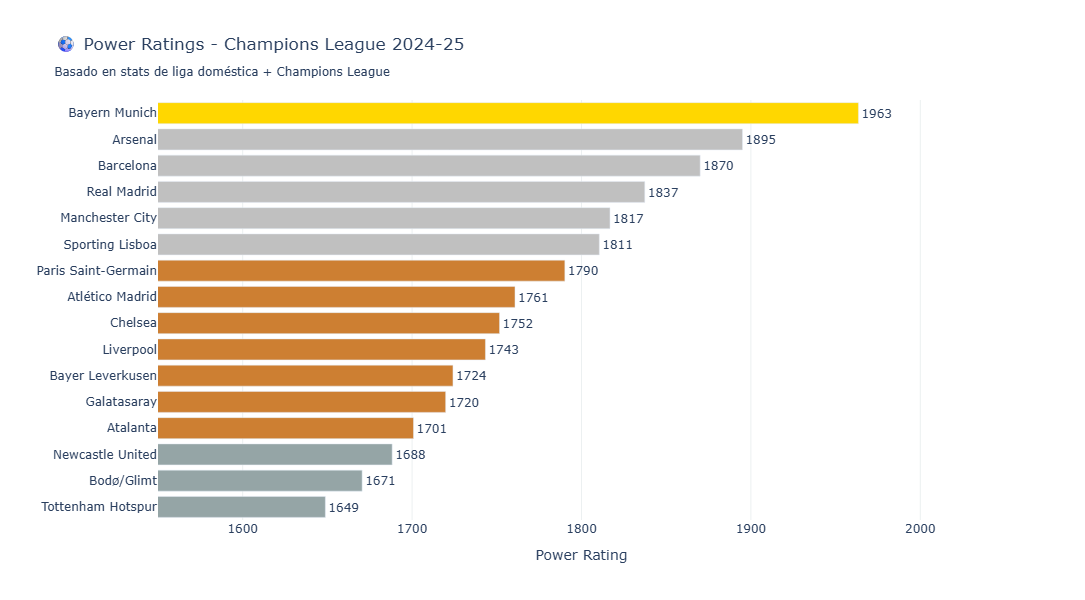

In [8]:
# Gráfico de barras horizontales
fig = go.Figure()

# Colores según nivel de rating
colors = []
for rating in df_rankings['power_rating']:
    if rating >= 1900:
        colors.append('#FFD700')  # Oro - Elite
    elif rating >= 1800:
        colors.append('#C0C0C0')  # Plata - Top
    elif rating >= 1700:
        colors.append('#CD7F32')  # Bronce - Competitivo
    else:
        colors.append('#95a5a6')  # Gris - Underdog

fig.add_trace(go.Bar(
    y=df_rankings['Equipo'][::-1],
    x=df_rankings['power_rating'][::-1],
    orientation='h',
    marker_color=colors[::-1],
    text=df_rankings['power_rating'][::-1].round(0).astype(int),
    textposition='outside',
    hovertemplate='<b>%{y}</b><br>Rating: %{x:.0f}<extra></extra>'
))

fig.update_layout(
    title='⚽ Power Ratings - Champions League 2024-25<br><sub>Basado en stats de liga doméstica + Champions League</sub>',
    xaxis_title='Power Rating',
    yaxis_title='',
    plot_bgcolor='white',
    height=600,
    font=dict(size=12),
    showlegend=False
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1', range=[1550, 2050])
fig.show()

## 7. Función de Probabilidad

Calcular probabilidad de victoria usando ratings:

In [9]:
def calcular_probabilidad(rating_a, rating_b):
    """
    Calcular probabilidad de victoria de A vs B
    
    Fórmula tipo ELO:
    P(A gana) = 1 / (1 + 10^((ratingB - ratingA)/400))
    """
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

# Crear diccionario de ratings para acceso rápido
ratings_dict = dict(zip(df_rankings['Equipo'], df_rankings['power_rating']))

print("\n⚔️ ENFRENTAMIENTOS DE OCTAVOS - PROBABILIDADES:\n")

enfrentamientos = [
    ('Galatasaray', 'Liverpool'),
    ('Newcastle United', 'Barcelona'),
    ('Atlético Madrid', 'Tottenham Hotspur'),
    ('Atalanta', 'Bayern Munich'),
    ('Bayer Leverkusen', 'Arsenal'),
    ('Paris Saint-Germain', 'Chelsea'),
    ('Bodø/Glimt', 'Sporting Lisboa'),
    ('Real Madrid', 'Manchester City')
]

for local, visitante in enfrentamientos:
    rating_local = ratings_dict[local]
    rating_visitante = ratings_dict[visitante]
    
    prob_local = calcular_probabilidad(rating_local, rating_visitante)
    prob_visitante = 1 - prob_local
    
    print(f"{local} vs {visitante}")
    print(f"  Ratings: {rating_local:.0f} vs {rating_visitante:.0f}")
    print(f"  Probabilidad: {prob_local*100:.1f}% - {prob_visitante*100:.1f}%")
    print()


⚔️ ENFRENTAMIENTOS DE OCTAVOS - PROBABILIDADES:

Galatasaray vs Liverpool
  Ratings: 1720 vs 1743
  Probabilidad: 46.6% - 53.4%

Newcastle United vs Barcelona
  Ratings: 1688 vs 1870
  Probabilidad: 26.0% - 74.0%

Atlético Madrid vs Tottenham Hotspur
  Ratings: 1761 vs 1649
  Probabilidad: 65.6% - 34.4%

Atalanta vs Bayern Munich
  Ratings: 1701 vs 1963
  Probabilidad: 18.1% - 81.9%

Bayer Leverkusen vs Arsenal
  Ratings: 1724 vs 1895
  Probabilidad: 27.2% - 72.8%

Paris Saint-Germain vs Chelsea
  Ratings: 1790 vs 1752
  Probabilidad: 55.5% - 44.5%

Bodø/Glimt vs Sporting Lisboa
  Ratings: 1671 vs 1811
  Probabilidad: 30.9% - 69.1%

Real Madrid vs Manchester City
  Ratings: 1837 vs 1817
  Probabilidad: 53.0% - 47.0%



## 8. Guardar Power Ratings

In [10]:
# Guardar ratings finales
df_rankings.to_csv('../data/processed/power_ratings_final.csv', index=False)
print("\n✅ Power Ratings guardados en: data/processed/power_ratings_final.csv")


✅ Power Ratings guardados en: data/processed/power_ratings_final.csv


## 📝 Próximos Pasos

**Mañana (Sábado):**
1. Simulación de partidos individuales (ida + vuelta)
2. Lógica de gol visitante
3. Simulación de octavos completos

**Domingo:**
4. Simulación de cuartos, semis, final
5. Monte Carlo (10,000 torneos completos)
6. Probabilidades de campeón
7. Visualizaciones finales